In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import branes
import matplotlib.pyplot as plt
import matplotlib.colors as colors
# import multiprocess as mp
from sklearn.decomposition import PCA
import glob

In [17]:
plt.rcParams['text.usetex'] = True
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'black'
plt.rcParams['legend.facecolor'] = '0.25'

# TO-DO:
 - Add MSSM terms?
 - Add SUSY check when fewer than 3 stacks have 2 or more nonzero YI
 - Make sure SUSY checks are unbiased: checking ratios and in optimizing with choice of free U^I

## Main loop

array([0.023, 0.024, 0.025, 0.026, 0.027, 0.028, 0.029, 0.03 ])

In [179]:
numStacks = 5
bix2 = [0, 0, 0]
minNa = 1
weights = [0.3, 0.1, 0.6]

popSize = 1000
numSurvive = 100
numGens = 100

xoverProb = 0.9

mutWindBnml = 0.013
mutWindZero = 0
mutWindSign = mutWindBnml
mutPairRand = 0
mutPairPerm = 0
mutPairSign = mutWindBnml
mutStckRand = 0
mutSizeBnml = mutWindBnml

mutRates = [mutWindBnml, mutWindZero, mutWindSign,
            mutPairRand, mutPairPerm, mutPairSign,
            mutStckRand, mutSizeBnml]

method = '3'

# filePath = ('test_xoverProb_ns=%d_bix2=%d%d%d_w=%02d%02d%02d_popsize=%d_gmax=%d_mutbnml=sgn=%03d/xoverProb=%d.npy' % (numStacks, bix2[0], bix2[1], bix2[2], 10*weights[0], 10*weights[1], 10*weights[2], popSize, numGens, 100*mutWindBnml, 100*xoverProb))
# filePath = ('test_mutRate_ns=%d_bix2=%d%d%d_w=%02d%02d%02d_popsize=%d_gmax=%d_xoverProb=%d/mutProb=%04d.npy' % (numStacks, bix2[0], bix2[1], bix2[2], 10*weights[0], 10*weights[1], 10*weights[2], popSize, numGens, 100*xoverProb, 1000*mutWindBnml))
filePath = ('test_xoMeth_ns=%d_bix2=%d%d%d_w=%02d%02d%02d_popsize=%d_gmax=%d_xoverProb=%d_mutProb=%04d/method=%s.npy' % (numStacks, bix2[0], bix2[1], bix2[2], 10*weights[0], 10*weights[1], 10*weights[2], popSize, numGens, 100*xoverProb, 1000*mutWindBnml, method))

In [180]:
nRuns = 50
progress = False
save = True

branes.GA(nRuns, numGens, popSize, numSurvive,
          numStacks, bix2, minNa, weights,
          xoverProb, mutRates, progress, save, filePath)

Run  1

Run  2
	First found at generation :   37
	          Solutions found : 15949
	   Unique solutions found :  238

Run  3

Run  4
	First found at generation :   42
	          Solutions found : 14433
	   Unique solutions found :  239

Run  5

Run  6

Run  7

Run  8

Run  9

Run 10
	First found at generation :   25
	          Solutions found : 17834
	   Unique solutions found :  308

Run 11

Run 12

Run 13

Run 14
	First found at generation :   49
	          Solutions found : 13322
	   Unique solutions found :  159

Run 15

Run 16
	First found at generation :   71
	          Solutions found : 3807
	   Unique solutions found :  119

Run 17

Run 18

Run 19
	First found at generation :   54
	          Solutions found : 8551
	   Unique solutions found :  160

Run 20

Run 21

Run 22

Run 23
	First found at generation :   46
	          Solutions found : 13178
	   Unique solutions found :  202

Run 24

Run 25

Run 26

Run 27

Run 28

Run 29
	First found at generation :   53
	          Solut

## Testing: cross-over method

[[  1   2   3   4]
 [150 150 150 150]]


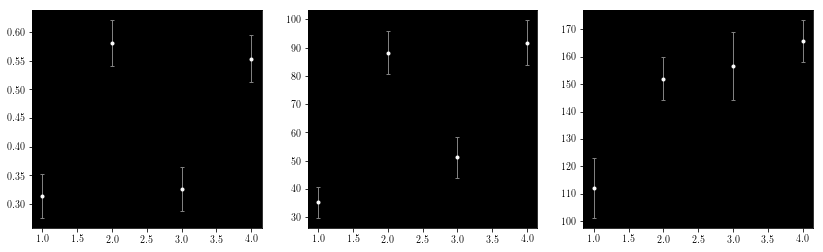

In [181]:
files = glob.glob('test_xoMeth*/*.npy')

method = np.array([int(f[-5]) for f in files])
solnCounts = np.array([np.load(f) for f in files])
numRuns = np.array([len(x) for x in solnCounts])

probs = np.array([np.mean(s>0) for s in solnCounts])
err1sig = np.sqrt(probs * (1-probs) / numRuns)

means = np.array([np.mean(s) for s in solnCounts])
std = np.array([np.std(s)/np.sqrt(len(s)-1) for s in solnCounts])

foundMeans = np.array([np.mean(s[s>0]) for s in solnCounts])
foundStd = np.array([np.std(s[s>0])/np.sqrt(len(s[s>0])-1) for s in solnCounts])

print(np.array([method, numRuns]))

fig, ax = plt.subplots(1, 3, figsize=(14,4))
ax[0].errorbar(method, probs,      yerr=err1sig,  fmt='ow', ms=3, ecolor='gray', elinewidth=1, capsize=2)
ax[1].errorbar(method, means,      yerr=std,      fmt='ow', ms=3, ecolor='gray', elinewidth=1, capsize=2)
ax[2].errorbar(method, foundMeans, yerr=foundStd, fmt='ow', ms=3, ecolor='gray', elinewidth=1, capsize=2)

plt.show()

## Testing: mutation rates

C:\Users\gerg1\Anaconda3\lib\site-packages\ipykernel_launcher.py:14: RuntimeWarning: invalid value encountered in double_scalars
  


[[ 0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  1.   1.1  1.2  1.3  1.4
   1.5  1.6  1.7  1.8  1.9  2.   2.1  2.2  2.3  2.4  2.5  2.6  2.7  2.8
   2.9  3. ]
 [40.  40.  40.  40.  40.  40.  40.  40.  40.  40.  40.  40.  40.  40.
  60.  40.  40.  40.  40.  40.  40.  40.  40.  40.  40.  40.  40.  40.
  40.  40. ]]


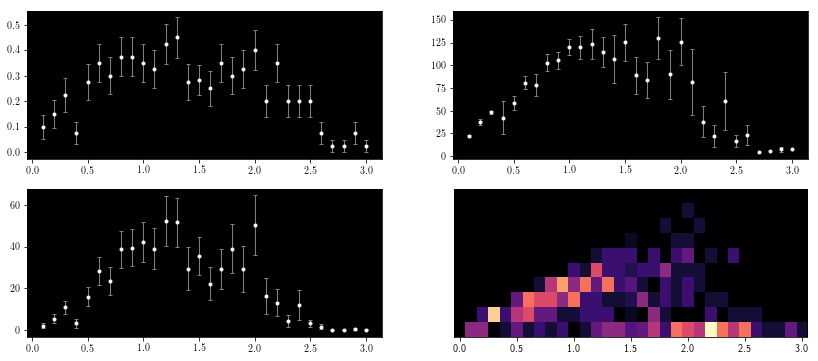

In [128]:
files = glob.glob("test_mutRate*/*.npy")

rates = np.array([int(f[79:-4])/1000 for f in files])
solnCounts = np.array([np.load(f) for f in files])
numRuns = np.array([len(x) for x in solnCounts])

probs = np.array([np.mean(s>0) for s in solnCounts])
err1sig = np.sqrt(probs * (1-probs) / numRuns)

means = np.array([np.mean(s) for s in solnCounts])
std = np.array([np.std(s)/np.sqrt(len(s)-1) for s in solnCounts])

foundMeans = np.array([np.mean(s[s>0]) for s in solnCounts])
foundStd = np.array([np.std(s[s>0])/np.sqrt(len(s[s>0])-1) for s in solnCounts])

hist = np.zeros([10, 31])
for i in range(len(rates)):
    for c in solnCounts[i]:
        if c > 0:
            hist[int(c/40), int(1000*rates[i])] += 1/len(solnCounts[i])


print(np.array([100*rates, numRuns]))

fig, ax = plt.subplots(2, 2, figsize=(14,6))
ax[0, 0].errorbar(100*rates, probs,      yerr=err1sig,  fmt='ow', ms=3, ecolor='gray', elinewidth=1, capsize=2)
ax[1, 0].errorbar(100*rates, means,      yerr=std,      fmt='ow', ms=3, ecolor='gray', elinewidth=1, capsize=2)
ax[0, 1].errorbar(100*rates, foundMeans, yerr=foundStd, fmt='ow', ms=3, ecolor='gray', elinewidth=1, capsize=2)
ax[1, 1].imshow(hist, origin='lower', cmap='magma')

ax[1, 1].set_aspect(1.3)
ax[1, 1].set_xticks(np.linspace(0,30,7))
ax[1, 1].set_xticklabels(np.linspace(0,3,7))
ax[1, 1].set_yticks([])

# plt.savefig('mutProb_test.png')

plt.show()

## Testing: cross-over probability

C:\Users\gerg1\Anaconda3\lib\site-packages\ipykernel_launcher.py:14: RuntimeWarning: invalid value encountered in double_scalars
  


[[ 0.6   0.61  0.62  0.63  0.64  0.65  0.66  0.67  0.68  0.69  0.7   0.71
   0.72  0.73  0.74  0.75  0.76  0.77  0.78  0.79  0.8   0.81  0.82  0.83
   0.84  0.85  0.86  0.87  0.88  0.89  0.9   0.91  0.92  0.93  0.94  0.95
   0.96  0.97  0.98  0.99  1.  ]
 [60.   80.   40.   40.   80.   40.   20.   40.   40.   20.   40.   40.
  40.   40.   40.   40.   20.   40.   40.   40.   40.   20.   40.   20.
  20.   40.   40.   60.   40.   30.   40.   20.   60.   40.   40.   40.
  40.   40.   40.   40.   60.  ]]


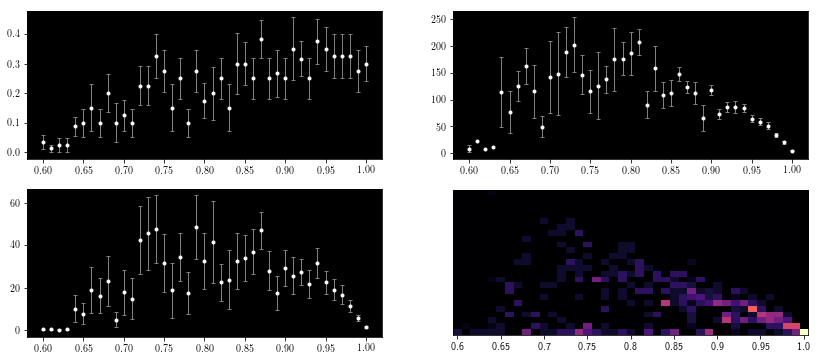

In [19]:
files = np.roll(glob.glob("test_xoverProb*/*.npy"), -1)

xoverProbs = np.array([int(f[86:-4])/100 for f in files])
solnCounts = np.array([np.load(f) for f in files])
numRuns = np.array([len(x) for x in solnCounts])

probs = np.array([np.mean(s>0) for s in solnCounts])
err1sig = np.sqrt(probs * (1-probs) / numRuns)

means = np.array([np.mean(s) for s in solnCounts])
std = np.array([np.std(s)/np.sqrt(len(s)-1) for s in solnCounts])

foundMeans = np.array([np.mean(s[s>0]) for s in solnCounts])
foundStd = np.array([np.std(s[s>0])/np.sqrt(len(s[s>0])-1) for s in solnCounts])

hist = np.zeros([25, 41])
for i in range(len(xoverProbs)):
    for c in solnCounts[i]:
        if c > 0:
            hist[int(c/20), int(100*xoverProbs[i])-60] += 1/len(solnCounts[i])


print(np.array([xoverProbs, numRuns]))

fig, ax = plt.subplots(2, 2, figsize=(14,6))
ax[0, 0].errorbar(xoverProbs, probs,      yerr=err1sig,  fmt='ow', ms=3, ecolor='gray', elinewidth=1, capsize=2)
ax[1, 0].errorbar(xoverProbs, means,      yerr=std,      fmt='ow', ms=3, ecolor='gray', elinewidth=1, capsize=2)
ax[0, 1].errorbar(xoverProbs, foundMeans, yerr=foundStd, fmt='ow', ms=3, ecolor='gray', elinewidth=1, capsize=2)
ax[1, 1].imshow(hist, origin='lower', cmap='magma')

ax[1, 1].set_aspect(0.67)
ax[1, 1].set_xticks(np.linspace(0,40,9))
ax[1, 1].set_xticklabels(np.linspace(0.6,1,9))
ax[1, 1].set_yticks([])

# plt.savefig('xoverProb_test.png')

plt.show()

In [96]:
test = branes.individual(numStacks, bix2, minNa, weights)
test.stacks = np.array([
    [1,  1, 0, 1, 0, 1, 0],
    [1,  1, 0, 1, 0, 1, 0],
    [1,  3, 0, 2, 1, 1, -1],
    [1,  0, 1, 1, 1, -1, -1],
    [1,  1, 0, 0, 1, 0, 1]
])
test.updateFitness()
test.display()

{ -9.210340371976182 , 125000001.99999978 },
{ -8.240830859136583 , 17980625.603595734 },
{ -7.271321346296985 , 2586424.6013934826 },
{ -6.301811833457387 , 372045.9302039141 },
{ -5.332302320617789 , 53518.65498399229 },
{ -4.36279280777819 , 7700.102638325299 },
{ -3.393283294938592 , 1109.3334880125994 },
{ -2.423773782098994 , 161.2843732128913 },
{ -1.4542642692593954 , 24.91225888540536 },
{ -0.4847547564197967 , 5.295813623412933 },
{ 0.48475475641980204 , 2.474086273841529 },
{ 1.454264269259399 , 2.0681949347646063 },
{ 2.4237737820989977 , 2.009809499629393 },
{ 3.3932832949385965 , 2.001411047364606 },
{ 4.3627928077781934 , 2.000202972092399 },
{ 5.332302320617792 , 2.0000291965183634 },
{ 6.301811833457391 , 2.000004199772858 },
{ 7.271321346296988 , 2.0000006041162797 },
{ 8.240830859136588 , 2.0000000868991 },

   N_a |  n1  m1  n2  m2  n3  m3       X0  X1  X2  X3       Y0  Y1  Y2  Y3     SUSY-X     SUSY-Y
----------------------------------------------------------------

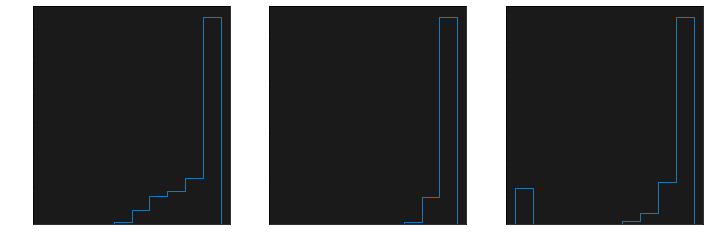

In [44]:
rewards = np.array([e.fitnessDetails[:3] for e in pop.elements])
tadRewards = rewards[:, 0]
KthRewards = rewards[:, 1]
susyRewards = rewards[:, 2]

fig, ax = plt.subplots(1, 3, figsize=(12,4))
ax[0].hist(tadRewards, range=(0, 1), histtype='step')
ax[1].hist(KthRewards, range=(0, 1), histtype='step')
ax[2].hist(susyRewards, range=(0, 1), histtype='step')
plt.show()

In [45]:
pop.displayFittest(3)


   N_a |  n1  m1  n2  m2  n3  m3       X0  X1  X2  X3       Y0  Y1  Y2  Y3     SUSY-X     SUSY-Y
--------------------------------------------------------------------------------------------------
    1 |   3  -1   1   2   2   1        6  -6   1   4       -2   2 -12  -3      0.0000      0.0000
    1 |   1  -6   1  -2   0   1        0   2   6   0       12   0   0  -1      0.0000     -0.0000
    2 |   3   2   0   1  -1  -2        0   6   0   2       -4   0   3   0      0.0000      0.0000
    1 |   0   1   1   0   0  -1        0   0   1   0        0   0   0   0      0.0000      0.0000
    2 |   1   0   1   0   1   0        1   0   0   0        0   0   0   0      0.0000      0.0000

   tadpole = 0.3000	= 0.30 x 1.0000		   0   0   0   0 	   0   0   0   0
  K-theory = 0.1000	= 0.10 x 1.00		   0   0   0   0
      SUSY = 0.6000	= 0.60 x 1.0000		  0.7979  0.0296  0.5984  0.0665
   fitness = 1.0000				   27.00    1.00   20.25    2.25


   N_a |  n1  m1  n2  m2  n3  m3       X0  X1  X2  X3       

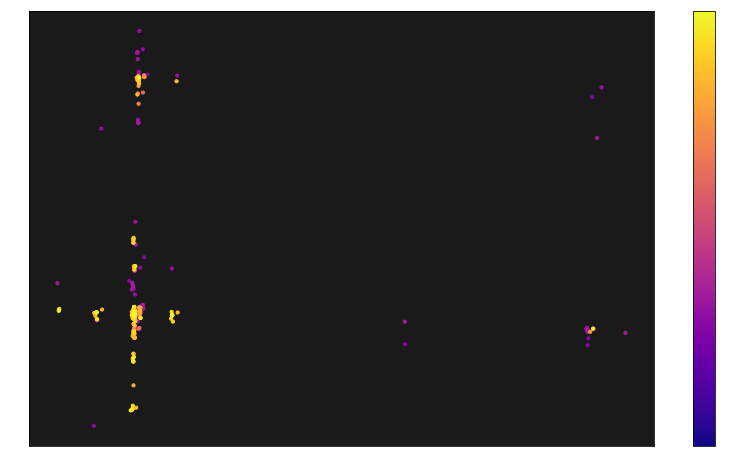

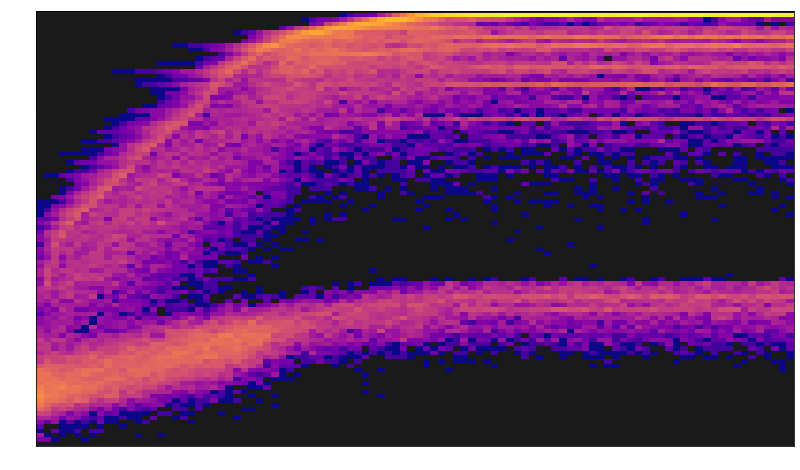

In [43]:
# PCA
sortOrder = np.argsort(fitnessDist[-1])
flatPopulation = [np.ravel(e.stacks) for e in pop.elements[sortOrder]]


pca = PCA(n_components=2)
pca.fit(flatPopulation)
x_pca, y_pca = pca.transform(flatPopulation).T

fig, ax = plt.subplots(1, figsize=(14,8))
scat = ax.scatter(x_pca, y_pca, c=fitnessDist[g, sortOrder], s=10,
                   cmap='plasma', norm=colors.Normalize(vmin=0, vmax=1))
plt.colorbar(scat)
plt.show()


# fitness distribution
bins = 100

fig, ax = plt.subplots(1, figsize=(14,8))
counts = np.array([np.histogram(fitnessDist[i], bins=bins, range=(0,1))[0]
                   for i in range(g)])
ax.matshow(counts.T, origin='lower', norm=colors.LogNorm(), cmap='plasma')
ax.xaxis.set_ticks_position("bottom")
plt.yticks([0,0.25*bins,0.50*bins,0.75*bins,bins], labels=[0,0.25,0.5,0.75,1])
ax.set_aspect(8/14 * g/bins)
plt.show()